In [1]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch
from utils import compare_statistics

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


In [2]:
train_original[0]['triplets'][:,2]

tensor([1, 3])

### Length of train and validation datasets

In [3]:
print(f"Training dataset containts {len(train_original)} graphs.")
print(f"Validation dataset containts {len(val_original)} graphs.")

Training dataset containts 3822 graphs.
Validation dataset containts 2382 graphs.


### Graphs with multiple relationships objects

In [4]:
# count how many graphs have objects with multiple relationships
count_train = 0
for el in train_original:
    objects = [i.item() for i in el['triplets'][:,1]]
    objects_set = set(objects)
    if len(objects) > len(objects_set):
        count_train +=1

count_val = 0
for el in val_original:
    objects = [i.item() for i in el['triplets'][:,1]]
    objects_set = set(objects)
    if len(objects) > len(objects_set):
        count_val +=1
print(f"Train dataset contains {count_train} graphs with multiple relationships objects ({((count_train*100)/len(train_original)):.2f}%)")
print(f"Validation dataset contains {count_val} graphs with multiple relationships objects ({((count_val*100)/len(train_original)):.2f}%)")

Train dataset contains 186 graphs with multiple relationships objects (4.87%)
Validation dataset contains 166 graphs with multiple relationships objects (4.34%)


### Number of objects in the graphs of train and validation datasets
Keep in mind that the number of nodes for each graph is always equal to the number of objecs+1 because there is always one verb for each graph

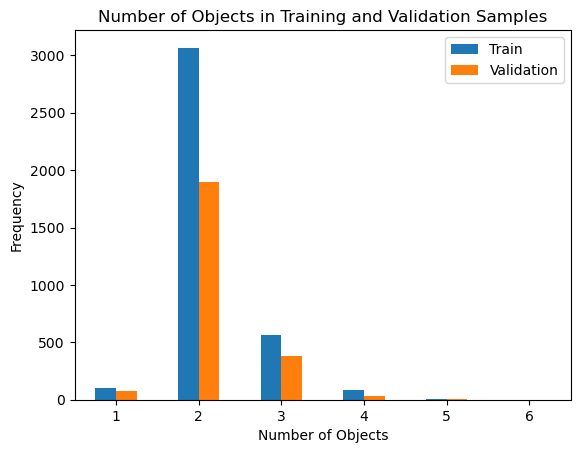

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training and validation sample
num_objects_train = [len(el['obj_indices']) for el in train_original]   # if you want the number of nodes instead of objects add 1 after len here...
num_objects_val = [len(el['obj_indices']) for el in val_original]       # ...and here

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Train')
objects_val_pd = pd.Series(num_objects_val, name='Validation')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_val_count = objects_val_pd.value_counts().sort_index()

# Combine both Series into a DataFrame
objects_count_df = pd.DataFrame({'Train': objects_train_count, 'Validation': objects_val_count}).fillna(0)

objects_count_df.plot.bar()
plt.xticks(rotation=0)
plt.title('Number of Objects in Training and Validation Samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()


### Percentage of actual relationships
Given the way we built our data, we have gt matrix for the relatioships of size 391x14 for each graph. For each graph only a few objects (usually 2 or 3 as we can see in the plot above), are present. This means that out of 391 lines for each graph usually only 3 or 4 have a "1" that is not in the last column (which represents the absence of a relationship).

In [6]:
objects = []
for el in train_original:
    objects.append(len(el['obj_indices']))

total_lines=391*len(train_original)
ones = sum(objects)
print(f"Number of lines with actual relationship: {(ones*100/total_lines):.2f} %")
# Since class 13 appears 99.44% of the times, I will weigh this class 0.01 
# (even though I could weigh it 0.0056)

Number of lines with actual relationship: 0.56 %


### Percentage frequency of the most common verbs in the dataset

In [7]:
# length of training and validation dataset
verbs_list_val = []
for el in val_original:
    verbs_list_val.append(el['verb_idx'].item())

verbs_list_train = []
for el in train_original:
    verbs_list_train.append(el['verb_idx'].item())
    
print(len(verbs_list_train))
print(len(verbs_list_val))

3822
2382


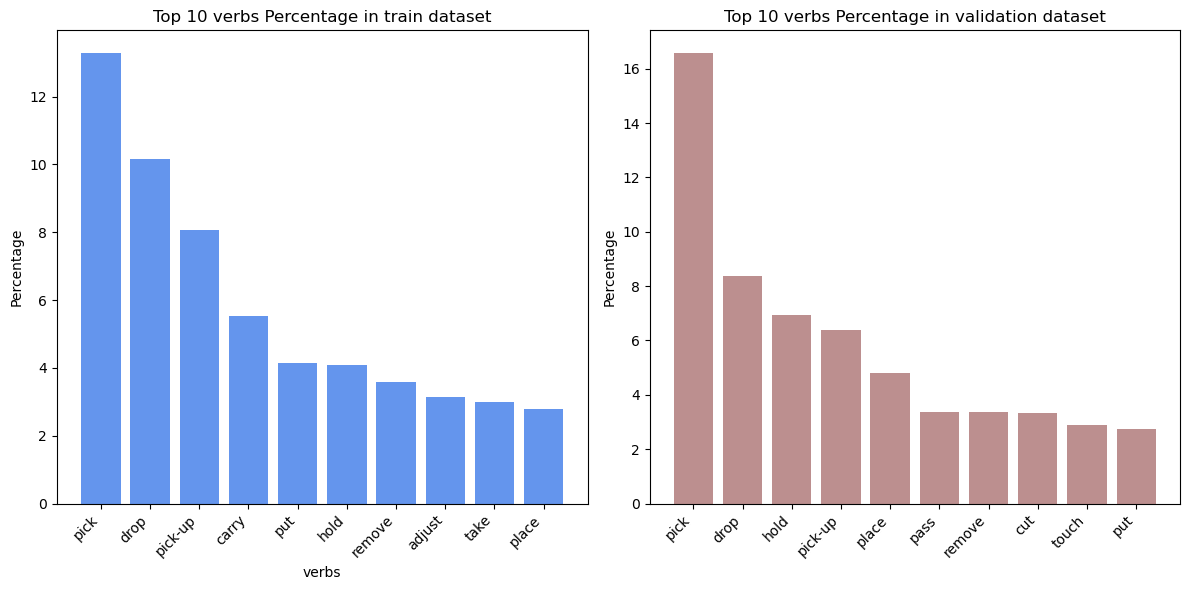

In [8]:
compare_statistics(verbs_list_train, verbs_list_val, verbs, 'train dataset', 'validation dataset', 'verbs')

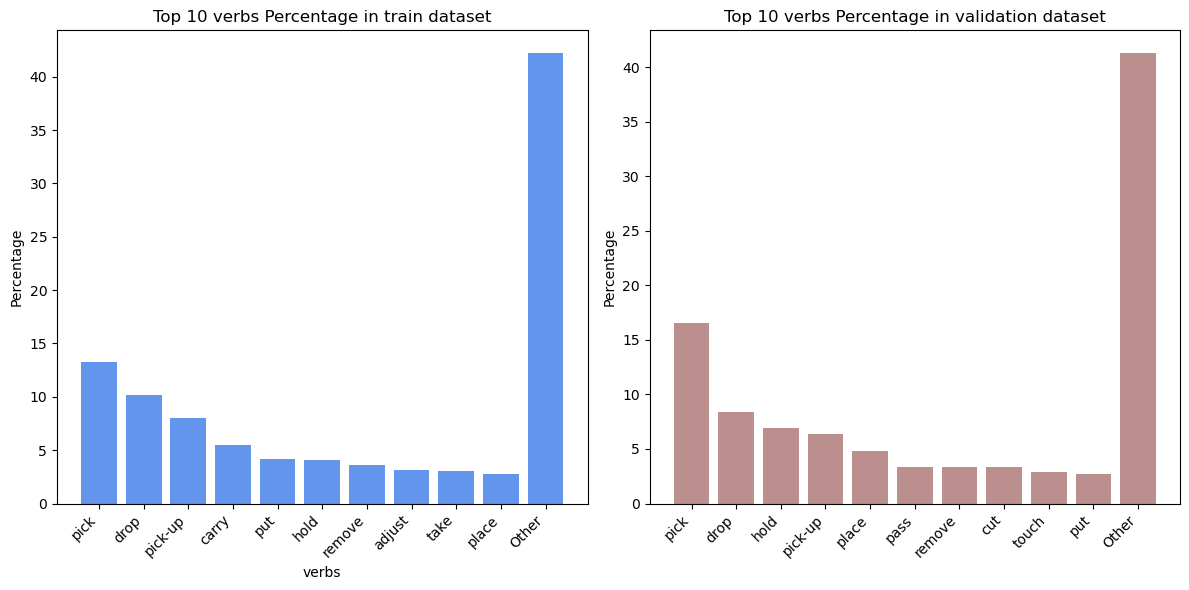

In [9]:
compare_statistics(verbs_list_train, verbs_list_val, verbs, 'train dataset', 'validation dataset', 'verbs', other=True)

In [13]:
from collections import Counter
c_val = Counter(verbs_list_val)
c_train = Counter(verbs_list_train)

# 395 is the number of times verb 89 ("picks") appears in the validation dataset
print(c_val.most_common(1)[0][1]/len(val_original))        # = 0.1658 like top1 verb prediction
# 199 is the number of times verb 36 ("drop") appears in the validation dataset
print((c_val.most_common(2)[0][1]+c_val.most_common(2)[1][1])/len(val_original))      # = 0.2493 like top2 verb prediction
# top5 and top10 are a bit different but if I keep summing up I obtain something very similar

top10_verbs_train = [el[0] for el in c_train.most_common(10)]
top10_verbs_train.sort()
print(top10_verbs_train)

top10_verbs_val = [el[0] for el in c_val.most_common(10)]
top10_verbs_val.sort()
print(top10_verbs_val)

print(sum(top10_verbs_val)/len(val_original))
print(sum(top10_verbs_train)/len(val_original))

0.1658270361041142
0.24937027707808565
[1, 12, 36, 58, 89, 91, 92, 108, 115, 162]
[26, 36, 58, 86, 89, 91, 92, 108, 115, 174]
0.36733837111670864
0.32073887489504616


### Percentage frequency of the most common objects in the dataset

In [54]:
objs_list_val = []
for el in val_original:
    for r in el['triplets']:
        objs_list_val.append(r[1].item())  

objs_list_train = []
for el in train_original:
    for r in el['triplets']:
        objs_list_train.append(r[1].item())  

print(len(objs_list_train))
print(len(objs_list_val))

8485
5299


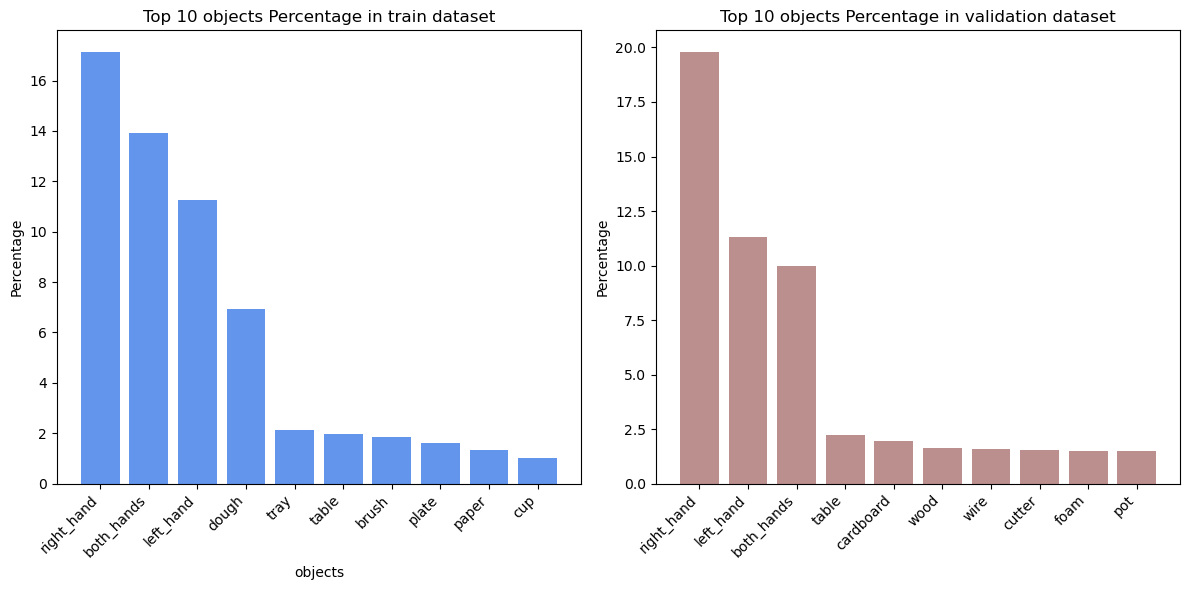

In [55]:
compare_statistics(objs_list_train, objs_list_val, objs, 'train dataset', 'validation dataset', 'objects', other=False)

### Percentage frequency of the most common relationships in the dataset

In [38]:
train_original[0]['triplets']

tensor([[162, 212,   1],
        [162, 171,   3]])

In [52]:
rels_list_val = []
for el in val_original:
    for r in el['triplets']:
        rels_list_val.append(r[2].item())  

rels_list_train = []
for el in train_original:
    for r in el['triplets']:
        rels_list_train.append(r[2].item())  

print(len(objs_list_train))
print(len(objs_list_val))

8297
5133


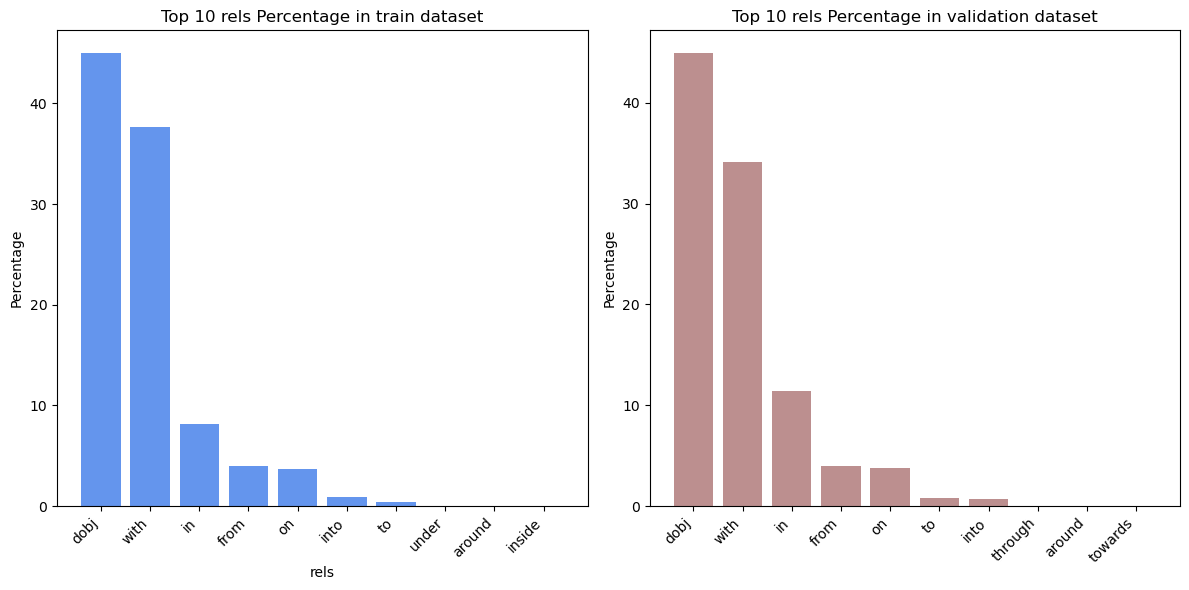

In [53]:
compare_statistics(rels_list_train, rels_list_val, rels, 'train dataset', 'validation dataset', 'rels', other=False)